In [1]:
!pip install scikit-learn xgboost

In [2]:
import numpy as np
import pandas as pd

text_emb = np.load("/kaggle/input/notebooks/navishaaagarwaal/02-feature-extraction/text_emb.npy")
img_emb = np.load("/kaggle/input/notebooks/navishaaagarwaal/02-feature-extraction/img_emb.npy")
hash_emb = np.load("/kaggle/input/notebooks/navishaaagarwaal/02-feature-extraction/hash_emb.npy")

hashtag_count = np.load("/kaggle/input/notebooks/navishaaagarwaal/02-feature-extraction/hashtag_count.npy")
hashtag_freq = np.load("/kaggle/input/notebooks/navishaaagarwaal/02-feature-extraction/hashtag_freq.npy")

df = pd.read_csv("/kaggle/input/notebooks/navishaaagarwaal/01-dataset-preparation/labeled.csv")

y = df["label"].values

print(text_emb.shape)
print(img_emb.shape)
print(hash_emb.shape)

(11902, 512)
(11902, 512)
(11902, 512)


In [3]:
from sklearn.model_selection import train_test_split

X_train_idx, X_test_idx, y_train, y_test = train_test_split(
    np.arange(len(y)),
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [4]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

def run_experiment(X, name):

    X_train = X[X_train_idx]
    X_test = X[X_test_idx]

    neg = np.sum(y_train == 0)
    pos = np.sum(y_train == 1)

    pos_weight = neg / pos

    model = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=pos_weight,
        eval_metric="logloss",
        tree_method="hist",
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    roc = roc_auc_score(y_test, y_prob)

    print("\n==============================")
    print(name)
    print("==============================")

    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc)

    return roc

In [5]:
X_text = text_emb

roc_text = run_experiment(X_text, "TEXT ONLY")


TEXT ONLY
              precision    recall  f1-score   support

           0       0.93      0.94      0.93      2083
           1       0.52      0.49      0.51       298

    accuracy                           0.88      2381
   macro avg       0.72      0.71      0.72      2381
weighted avg       0.88      0.88      0.88      2381

ROC-AUC: 0.8368858480444119


In [6]:
X_text_img = np.concatenate([
    text_emb,
    img_emb
], axis=1)

roc_text_img = run_experiment(X_text_img, "TEXT + IMAGE")


TEXT + IMAGE
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      2083
           1       0.51      0.49      0.50       298

    accuracy                           0.88      2381
   macro avg       0.72      0.71      0.72      2381
weighted avg       0.88      0.88      0.88      2381

ROC-AUC: 0.8426886556882658


In [7]:
X_text_img_hash = np.concatenate([
    text_emb,
    img_emb,
    hash_emb
], axis=1)

roc_text_img_hash = run_experiment(X_text_img_hash, "TEXT + IMAGE + HASHTAG")


TEXT + IMAGE + HASHTAG
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      2083
           1       0.49      0.48      0.48       298

    accuracy                           0.87      2381
   macro avg       0.71      0.70      0.70      2381
weighted avg       0.87      0.87      0.87      2381

ROC-AUC: 0.8255412141110363


In [8]:
X_full = np.load("/kaggle/input/notebooks/navishaaagarwaal/05-proposed-model/X_features.npy")

roc_full = run_experiment(X_full, "FULL ENGINEERED MODEL")


FULL ENGINEERED MODEL
              precision    recall  f1-score   support

           0       0.92      0.93      0.93      2083
           1       0.50      0.47      0.48       298

    accuracy                           0.87      2381
   macro avg       0.71      0.70      0.71      2381
weighted avg       0.87      0.87      0.87      2381

ROC-AUC: 0.8275855680533046


In [9]:
results = pd.DataFrame({
    "Feature_Set":[
        "Text Only",
        "Text + Image",
        "Text + Image + Hashtag",
        "Full Engineered Features"
    ],
    "ROC-AUC":[
        roc_text,
        roc_text_img,
        roc_text_img_hash,
        roc_full
    ]
})

results

,Feature_Set,ROC-AUC
0,Text Only,0.836886
1,Text + Image,0.842689
2,Text + Image + Hashtag,0.825541
3,Full Engineered Features,0.827586


In [10]:
np.save("/kaggle/working/best_features.npy", X_text_img)

In [11]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# Load features
X = np.load("/kaggle/working/best_features.npy")
df = pd.read_csv("/kaggle/input/notebooks/navishaaagarwaal/01-dataset-preparation/labeled.csv")

y = df["label"].values

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Handle imbalance
neg = np.sum(y_train == 0)
pos = np.sum(y_train == 1)

pos_weight = neg / pos

# Train model
model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=pos_weight,
    eval_metric="logloss",
    tree_method="hist"
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

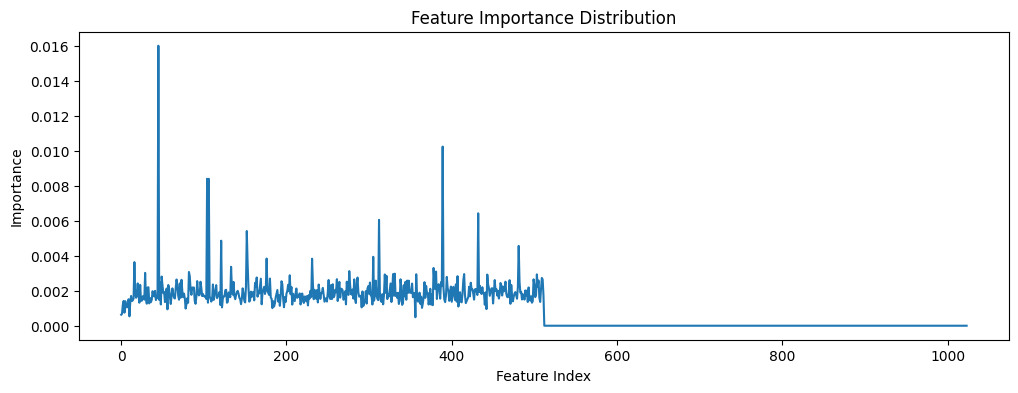

In [12]:
import matplotlib.pyplot as plt

importances = model.feature_importances_

plt.figure(figsize=(12,4))
plt.plot(importances)
plt.title("Feature Importance Distribution")
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.show()

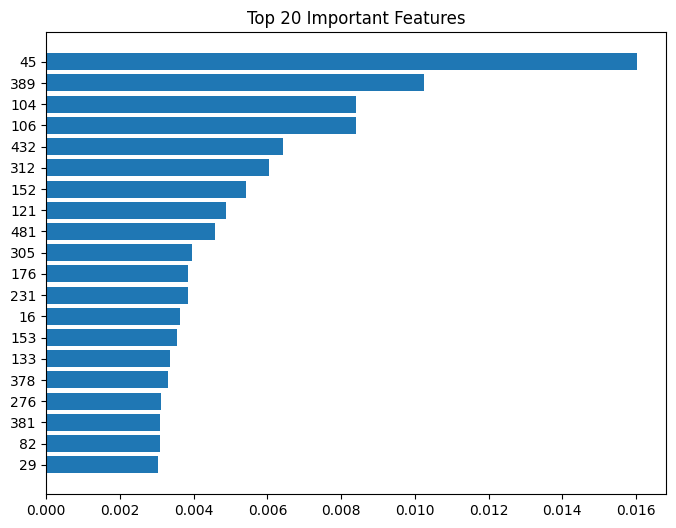

In [13]:
import numpy as np

top_idx = np.argsort(importances)[-20:]

plt.figure(figsize=(8,6))
plt.barh(range(20), importances[top_idx])
plt.yticks(range(20), top_idx)
plt.title("Top 20 Important Features")
plt.show()

In [14]:
np.save("/kaggle/working/best_features.npy", X_text_img)